# 10 — Uplift, Holdouts, and Incrementality Measurement
**Prerequisites:** `01_ab_testing_fundamentals.ipynb`; `09_segmentation_heterogeneity.ipynb`
(brief context on individual/segment-level effects).
**Connects to:** a **later causal-ML module** covers uplift *modeling* (CATE estimators, ML-based
targeting) in depth — this notebook keeps that part pointer-only and focuses on the
*experimental/measurement* side: holdouts and incrementality.

## Narrative thread
```
Uplift basics (brief) -> holdout groups in marketing -> long-run / halo effects
   -> ghost ads / PSA holdout methodology (Lewis & Rao 2015)
```

## Uplift, briefly

**Uplift** (a.k.a. incrementality, or the individual/segment-level treatment effect) is simply
$\tau_i = Y_i(1) - Y_i(0)$ at a finer grain than the overall ATE — "how much more likely is *this*
user to convert *because of* the treatment," rather than the population-average effect. Because
we never observe both potential outcomes for the same unit, uplift is always an **estimate**
built from a model or from group averages; building good individual-level uplift estimators
(ML-based CATE estimation) is genuinely a modeling problem, deferred to the later causal-ML
module. Here we care about a simpler but critically important use of the same idea:
**incrementality measurement via holdouts**, which is a pure experimental-design question, not a
modeling one.

## Holdout groups in marketing

A **holdout group** is a set of users deliberately excluded from a marketing action (an ad
campaign, a lifecycle email, a push notification campaign) so their subsequent behavior serves as
the counterfactual for "what would have happened anyway." Two flavors:

- **Standard experiment arm**: a holdout for a single campaign or feature, run for the duration of
  that campaign, analyzed like any other A/B test (this course's notebooks 01-08 apply directly).
- **Long-term / always-on holdout**: a small, *persistent* population permanently excluded from an
  entire marketing channel or a whole class of interventions (e.g. "2% of users never receive any
  retargeting ads"), maintained for months or years, used to measure the channel's *cumulative,
  long-run* incremental value rather than any single campaign's short-run lift.

The long-term holdout answers a different question than a standard A/B test: it captures
**halo effects** (does retargeting also lift organic engagement, brand search, offline
purchases?) and cross-campaign cannibalization that a single-campaign test would miss, at the
cost of tying up incremental measurement infrastructure indefinitely.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

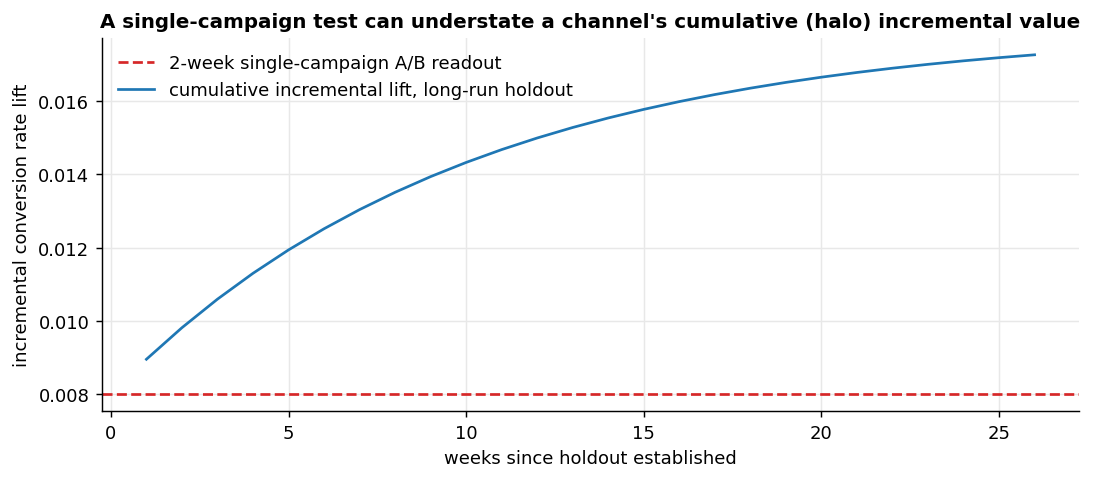

Short single-campaign estimate of lift: 0.800%
Long-run holdout estimate after 26 weeks: 1.726%
Understatement from relying only on the short campaign test: 116% of the true incremental value missed


In [2]:
# ── Illustrating a long-run holdout: cumulative incremental value vs. a single-campaign readout ──
np.random.seed(31)
weeks = np.arange(1, 27)
n_users = 50_000

# a single short campaign's measured lift (weeks 1-2 only) understates the channel's halo effect,
# which accrues gradually (word of mouth / brand recall / repeat visits) over the full holdout window
single_campaign_lift = 0.008         # measured in a 2-week standard A/B test
cumulative_halo_lift = 0.008 + 0.010 * (1 - np.exp(-weeks / 10))   # grows with a persistent holdout

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.axhline(single_campaign_lift, color='#d62728', ls='--', label='2-week single-campaign A/B readout')
ax.plot(weeks, cumulative_halo_lift, color='#1f77b4', label='cumulative incremental lift, long-run holdout')
ax.set_xlabel('weeks since holdout established'); ax.set_ylabel('incremental conversion rate lift')
ax.set_title('A single-campaign test can understate a channel\'s cumulative (halo) incremental value')
ax.legend(); plt.tight_layout(); plt.show()

print(f"Short single-campaign estimate of lift: {single_campaign_lift:.3%}")
print(f"Long-run holdout estimate after 26 weeks: {cumulative_halo_lift[-1]:.3%}")
print(f"Understatement from relying only on the short campaign test: "
      f"{(cumulative_halo_lift[-1]/single_campaign_lift - 1):.0%} of the true incremental value missed")

## Ghost ads / PSA holdouts: measuring advertising incrementality correctly

A famous methodological trap: naively comparing "users who saw an ad" to "users who didn't"
overstates the ad's effect, because ad delivery is *not random* — the ad platform's targeting
algorithm shows ads more to users who were already likely to convert (a selection effect, not a
treatment effect). **Lewis & Rao (2015)**, "The Unfavorable Economics of Measuring the Returns to
Advertising," formalize why measuring advertising's true causal lift is statistically much harder
than it looks: ad effects are typically small relative to the enormous baseline variance in
individual purchase behavior, so even well-designed experiments need very large holdout samples
to detect a real but modest incremental effect.

The clean solution used in industry is a **ghost ad / PSA (public service announcement) holdout**:
randomly assign users to see either the real ad or an unrelated "ghost" placeholder (or a
neutral PSA), so *both* groups go through the same ad-serving/targeting pipeline (same selection
process) and only the *creative content* differs. This isolates the causal effect of the ad
itself from the selection effect of who the algorithm chose to target — the same logic as a
standard A/B test, but designed specifically to defeat the ad-targeting selection bias described
above.


In [3]:
# ── Illustrating the ghost-ad idea: naive "exposed vs. unexposed" is confounded by targeting ──
np.random.seed(41)
n = 30_000
# latent propensity to convert anyway (also drives whether the targeting algorithm shows the real ad)
propensity = np.random.beta(2, 8, n)

# NAIVE (biased) design: ad platform shows the real ad preferentially to high-propensity users
shown_ad_naive = np.random.rand(n) < np.clip(0.3 + propensity, 0, 1)
converts_naive = np.random.rand(n) < propensity + 0.02 * shown_ad_naive  # true ad effect is only +0.02
naive_lift = converts_naive[shown_ad_naive].mean() - converts_naive[~shown_ad_naive].mean()

# GHOST-AD design: randomize real-ad vs. ghost-ad AFTER both groups already cleared targeting/selection
would_be_targeted = np.random.rand(n) < np.clip(0.3 + propensity, 0, 1)  # same targeting pipeline for both
target_pop = would_be_targeted   # only users the algorithm WOULD target enter the experiment
real_ad = np.zeros(n, dtype=bool)
real_ad[target_pop] = np.random.rand(target_pop.sum()) < 0.5   # 50/50 real ad vs ghost, within targeted pop
converts_ghost = np.random.rand(n) < propensity + 0.02 * real_ad
ghost_lift = (converts_ghost[target_pop & real_ad].mean()
              - converts_ghost[target_pop & ~real_ad].mean())

print(f"True incremental effect of the ad (by construction): 0.020")
print(f"Naive 'exposed vs unexposed' estimate (confounded by targeting selection): {naive_lift:+.3f}")
print(f"Ghost-ad / PSA holdout estimate (targeting held fixed, only creative randomized): {ghost_lift:+.3f}")

True incremental effect of the ad (by construction): 0.020
Naive 'exposed vs unexposed' estimate (confounded by targeting selection): +0.080
Ghost-ad / PSA holdout estimate (targeting held fixed, only creative randomized): +0.031


## Forward pointer: uplift modeling

Everything above measures *aggregate* or *group-level* incrementality experimentally. Building
individual-level uplift **models** — predicting $\tau_i$ per user with machine learning so
marketing spend or product treatment can be *targeted* to the users with the highest incremental
response (S-learners, T-learners, X-learners, causal forests, doubly robust uplift trees) — is a
substantial modeling topic on its own and is covered in the **later causal-ML module** of this
repository. Treat any uplift-modeling content you encounter elsewhere as building on the
measurement foundation established in this notebook, not as something to reproduce here.

## Key takeaways

| Concept | Statement |
|---|---|
| Uplift (brief) | Individual/segment treatment effect; estimating it well with ML is deferred to the causal-ML module |
| Holdouts | Standard-arm holdouts measure one campaign; long-run/always-on holdouts capture cumulative halo effects |
| Ghost ads / PSA | Randomize creative content within the *same* targeting pipeline to isolate the ad's causal effect from targeting selection bias |

## References

- Lewis, R. A., & Rao, J. M. (2015). The Unfavorable Economics of Measuring the Returns to Advertising. *Quarterly Journal of Economics*, 130(4), 1941-1973.
- Kohavi, R., Tang, D., & Xu, Y. (2020). *Trustworthy Online Controlled Experiments*, Ch. 21 (long-term holdouts and incrementality).
